In this tutorial we will examine block cipher modes of operations.

We will look at the basic blocks of modern crypto using Python. There are a number of crypto libraries in Python:
- `pycrypto` (oldest and most widely used)
- `m2crypto` (SWIG binding)
- `cryptography` (PY2, PY3, PyPy, OpenSSL CFFI binding)

We will use the `cryptography` library. `Cryptography` components are divided into different submodules. Following is a list of these submodules (not exhaustive)
- Primitive Crypto Blocks (`cryptography.hazmat`)
 - Message Digest and Hashing algorithms (`cryptography.hazmat.primitives.hashes`)
 - Symmetric encryption algorithms (`cryptography.hazmat.primitives.ciphers`)
 - Asymmetric encryption algorithms (`cryptography.hazmat.primitives.asymmetric`)
 - Key derivation functions (`cryptography.hazmat.primitives.kdf`)
- X.509 Ecosystem (`cryptography.x509`)
- Full high level crypto recipe (`cryptography.fernet`)

Run each cell, modify arguments and observer the output.

In [1]:
!pip install cryptography
from cryptography.hazmat.primitives.asymmetric import rsa
from cryptography.hazmat.primitives.asymmetric import padding as asympad
from cryptography.hazmat.primitives.ciphers import Cipher, algorithms, modes
from cryptography.hazmat.primitives import hashes, padding

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 4.0 MB 2.1 MB/s 


In [2]:
import math
import matplotlib.pyplot as plt
import os
from PIL import Image
from random import randint
import requests

In [3]:
def plt_img(plain_img, msg_img):
  f, ax = plt.subplots(1, 2, figsize=(12, 16))
  ax[0].imshow(plain_img)
  ax[1].imshow(msg_img)
  plt.show()

In [4]:
# A string
msg_str = "None of them noticed a large, tawny owl flutter past the window."

# A paragraph
msg_para = "Hermione: Are you sure that's a real spell? Well, it's not very \
good, is it? Of course I've only tried a few simple spells myself, and they've \
all worked for me. For example...{Hermione goes over and sits across from \
Harry. He points her hand at his glasses and Harry tenses} Oculus Reparo. {The \
glasses, which noseband is battered, are repaired. Harry takes them off, amazed.\
} That's better, isn't it? Holy Cricket, you're Harry Potter. I'm Hermione \
Granger...and you are...?"

# Two numbers
msg_num1 = 19
msg_num2 = 3

# A dataset
msg_data = [msg_str, msg_para, msg_num1, msg_num2]

# An image
url = "https://1.bp.blogspot.com/-O8FQac8ZU0U/XpVodd4zyCI/AAAAAAAAFeA/_gxAE-hJ4q8uuhbukYd6ugvprqfB11SmACK4BGAsYHg/tux.png"
plain_img = Image.open(requests.get(url, stream=True).raw)

# Caesar Cipher

In cryptography, a Caesar cipher, also known as Caesar's cipher, the shift cipher, Caesar's code or Caesar shift, is one of the simplest and most widely known encryption techniques. It is a type of substitution cipher in which each letter in the plaintext is replaced by a letter some fixed number of positions down the alphabet. For example, with a left shift of 3, D would be replaced by A, E would become B, and so on. The method is named after Julius Caesar, who used it in his private correspondence.

The encryption step performed by a Caesar cipher is often incorporated as part of more complex schemes, such as the Vigenère cipher, and still has modern application in the ROT13 system. As with all single-alphabet substitution ciphers, the Caesar cipher is easily broken and in modern practice offers essentially no communications security.

In [5]:
def enc_caesar(text, s):
  result = ""
  for i in range(len(text)):
    char = text[i]
    if (char.isupper()):
      result += chr((ord(char) + s - 65) % 26 + 65)
    elif (char.islower()):
      result += chr((ord(char) + s - 97) % 26 + 97)
    else:
      result += chr((ord(char) + s))
  return result

In [6]:
# Caesar shift
s = 3

In [7]:
for data in msg_data:
  data = str(data)
  print("Plain Text : " + data)
  print("Shift Pattern : " + str(s))
  print("Cipher Text: " + enc_caesar(data, s))
  print()

Plain Text : None of them noticed a large, tawny owl flutter past the window.
Shift Pattern : 3
Cipher Text: Qrqh#ri#wkhp#qrwlfhg#d#odujh/#wdzqb#rzo#ioxwwhu#sdvw#wkh#zlqgrz1

Plain Text : Hermione: Are you sure that's a real spell? Well, it's not very good, is it? Of course I've only tried a few simple spells myself, and they've all worked for me. For example...{Hermione goes over and sits across from Harry. He points her hand at his glasses and Harry tenses} Oculus Reparo. {The glasses, which noseband is battered, are repaired. Harry takes them off, amazed.} That's better, isn't it? Holy Cricket, you're Harry Potter. I'm Hermione Granger...and you are...?
Shift Pattern : 3
Cipher Text: Khuplrqh=#Duh#brx#vxuh#wkdw*v#d#uhdo#vshooB#Zhoo/#lw*v#qrw#yhub#jrrg/#lv#lwB#Ri#frxuvh#L*yh#rqob#wulhg#d#ihz#vlpsoh#vshoov#pbvhoi/#dqg#wkhb*yh#doo#zrunhg#iru#ph1#Iru#hadpsoh111~Khuplrqh#jrhv#ryhu#dqg#vlwv#dfurvv#iurp#Kduub1#Kh#srlqwv#khu#kdqg#dw#klv#jodvvhv#dqg#Kduub#whqvhv#Rfxoxv#Uhsdur1#~Wkh#jodvvhv/

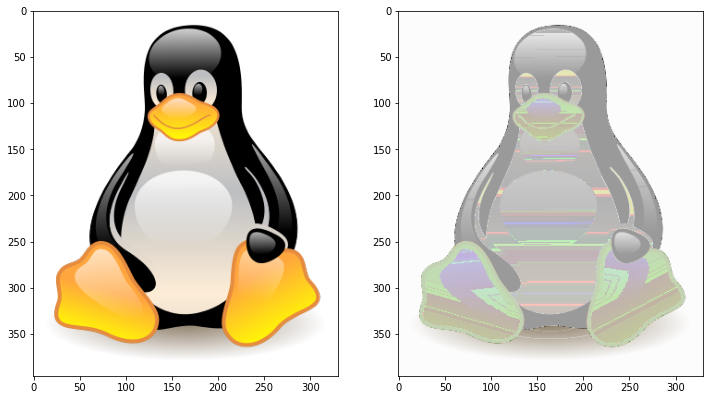

In [8]:
msg_img = Image.open(requests.get(url, stream=True).raw)
w, h = msg_img.size
pix = msg_img.load()

for i in range(w):
  for j in range(h):
    r, g, b, p = pix[i, j]
    r = ord(enc_caesar(chr(r), s))
    g = ord(enc_caesar(chr(g), s))
    b = ord(enc_caesar(chr(b), s))
    p = ord(enc_caesar(chr(p), s))
    pix[i, j] = (r, g, b, p)

plt_img(plain_img, msg_img)

In [9]:
ciph_num1 = enc_caesar(chr(msg_num1), s)
ciph_num2 = enc_caesar(chr(msg_num2), s)

# Add two numbers
ciph_add = ord(ciph_num1) + ord(ciph_num2)
print("Encrypted Addition: " + str(ciph_add))
plain_add = ciph_add - (2 * s)
print("Decrypted Addition: " + str(plain_add))
print()

# Multiply two numbers
ciph_mul = ord(ciph_num1) * ord(ciph_num2)
print("Encrypted Multiplication: " + str(ciph_mul))
plain_mul = ciph_mul - (s ** 2) - (plain_add * s)
print("Decrypted Multiplication: " + str(plain_mul))

Encrypted Addition: 28
Decrypted Addition: 22

Encrypted Multiplication: 132
Decrypted Multiplication: 57


# Symmetric Encryption

In the following we look at the symmetric encryption algorithms. In symmetric crpto, we use the same key for encryption and decryption. Therefore, the two parties needs to establish a secret key between them. It's up to 1000 times faster than asymmetric encryption.

# Advanced Encryption Algorithm (AES)

AES is based on Rijndael encryption algorithm, designed by Joan Daemen and Vincent Rijmen. It was one of the algorithms submitted to U.S. National Institute of Standards and Technology (NIST) to replace DES and 3DES. It was published in 1998 and accepted and standardized in 2001.

- AES supports key sizes of 128/192/256 bits
- Block size: 128 bit
- It's iterative rather than Feistel cipher
- Treats data in 4 groups of 4 bytes
- Operates on an entire block in every round
- Resistant against known attacks
- Speed and code compactness on many CPUs
- Rijndael block and key size vary between 128, 192, 256
- However, in AES block size in 128
- Number of rounds a function of key size
 - 128 bits 10 rounds
 - 192 bits 12 rounds
 - 256 bits 14 rounds
- Today most implementations use the CPU support (Intel AES-NI)

In [10]:
def aes_string(cipher, data):
  data = str(data)
  print(b"Plain Text : " + data.encode())

  padder = padding.PKCS7(algorithms.AES.block_size).padder()
  padded_data = padder.update(data.encode()) + padder.finalize()
  print(b"Padded Text : " + padded_data)

  encryptor = cipher.encryptor()
  ct = encryptor.update(padded_data) + encryptor.finalize()
  print(b"Padded Cipher : " + ct)

  decryptor = cipher.decryptor()
  data = decryptor.update(ct) + decryptor.finalize()
  print(b"Padded Data : " + data)

  unpadder = padding.PKCS7(algorithms.AES.block_size).unpadder()
  data = unpadder.update(data) + unpadder.finalize()
  print(b"Unpadded Data : " + data)

In [11]:
def aes_image(cipher, url):
  msg_img = Image.open(requests.get(url, stream=True).raw)
  msg_img = msg_img.tobytes(encoder_name='raw')
  padder = padding.PKCS7(algorithms.AES.block_size).padder()
  padded_data = padder.update(msg_img) + padder.finalize()
  
  encryptor = cipher.encryptor()
  msg_img = encryptor.update(padded_data) + encryptor.finalize()
  msg_img = Image.frombuffer(plain_img.mode, plain_img.size, msg_img)
  plt_img(plain_img, msg_img)

In [12]:
def run_aes(cipher):
  for data in msg_data:
    aes_string(cipher, data)
    print()
  aes_image(cipher, url)

In [13]:
# AES keys
key = os.urandom(16)
iv = os.urandom(16)

# Block cipher mode of operation

To encrypt messages of arbitrary size with block ciphers, we use the following algorithms, called the modes of operation. They define how to encrypt each block of the plaintext to produce the corresponding cipher text block. Some of these are complemetly insecure (ECB) and should not be used.

- Electronic Codebook (ECB)
- Cipher Block Chaining (CBC)
- Cipher Feedback (CFB)
- Output Feedback (OFB)
- Counter (CTR)

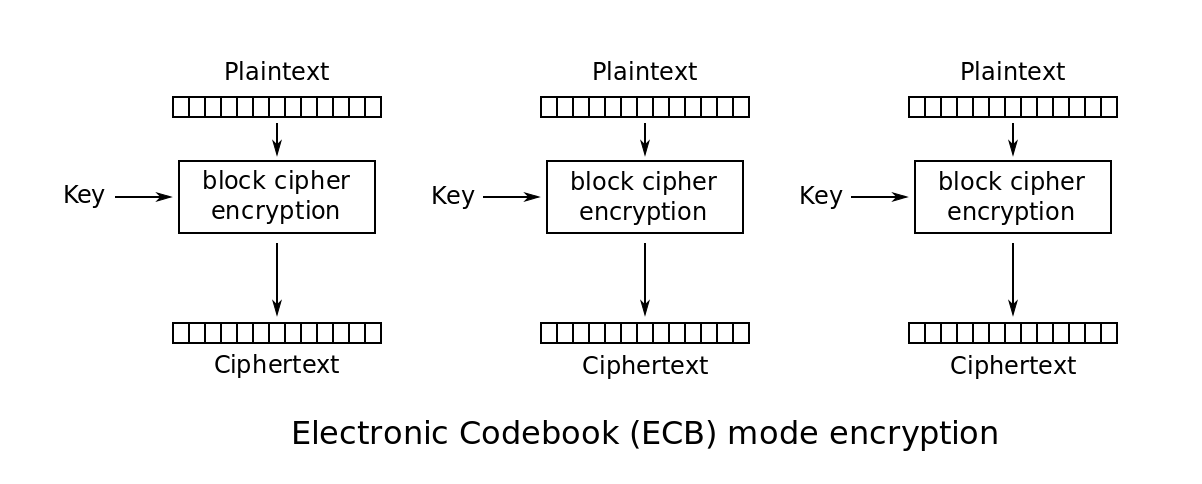

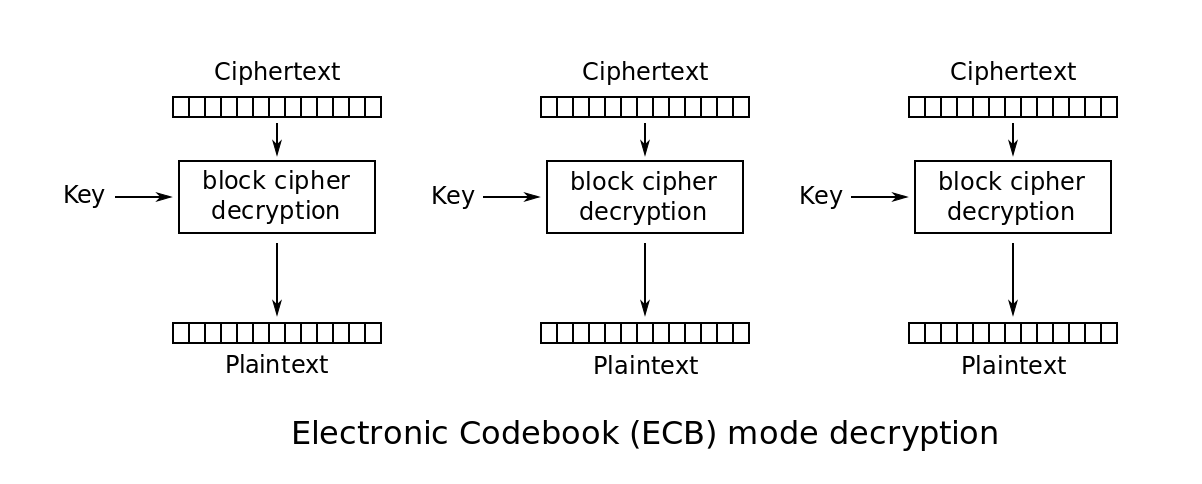

b'Plain Text : None of them noticed a large, tawny owl flutter past the window.'
b'Padded Text : None of them noticed a large, tawny owl flutter past the window.\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10'
b'Padded Cipher : `\xf4T&\x8b_i\xb0\xf7\x0b\x14M\x15\xd1\xff\xfdo\xa3\x05\xf1\xbe\xc6\xe5@S\x94Z\x8b+\xce\xb0\xe4}HA\xe5=\x15\x06\x93\xc2N\x94\xe5N\xdb\x0fy\x80H\x98\x92\xea9\\fb\xf4~&}\x96\xf0\xf4\xaa"\x81a\xeb\x8e=\xecM\xd4\xado\xad;\xfa\xf7'
b'Padded Data : None of them noticed a large, tawny owl flutter past the window.\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10'
b'Unpadded Data : None of them noticed a large, tawny owl flutter past the window.'

b"Plain Text : Hermione: Are you sure that's a real spell? Well, it's not very good, is it? Of course I've only tried a few simple spells myself, and they've all worked for me. For example...{Hermione goes over and sits across from Harry. He points her hand at his glasses and Harry tenses} Oculus

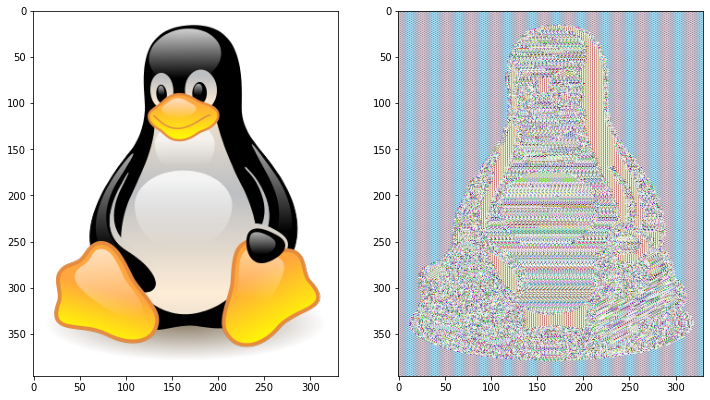

In [14]:
cipher = Cipher(algorithms.AES(key), modes.ECB())
run_aes(cipher)

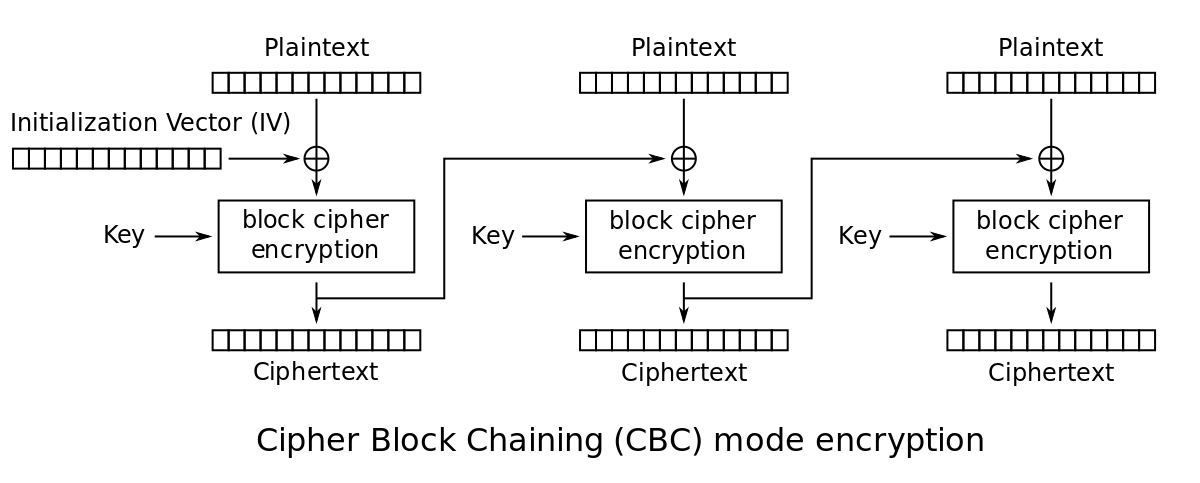

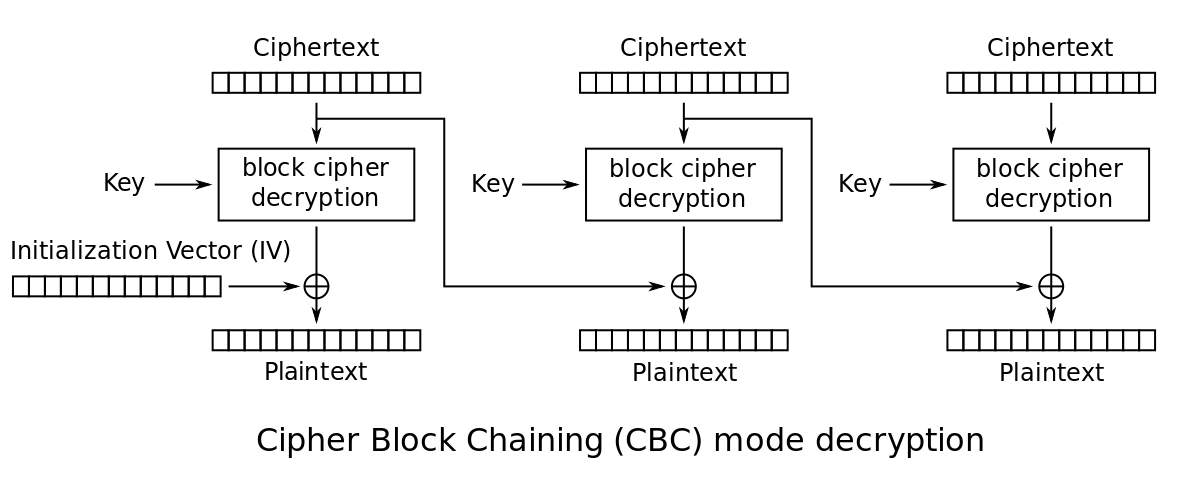

b'Plain Text : None of them noticed a large, tawny owl flutter past the window.'
b'Padded Text : None of them noticed a large, tawny owl flutter past the window.\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10'
b"Padded Cipher : \xa6\xe5\xa6\x9c)J\n\t\xdc\xfb8\x14\xc2X\xa8\xe4P\x18f\xb9\x11>\x1e5{\x81h\xc4\xb8\xe0\xcd\xed\x1cM1w\xa5\xab\xf5D\xf1(2\xba\x86\xd1'\xd1v\xd5\xe3\xf7\xf5\xb0\x1f\xcdO\xbf\x95\xf5}\xe1\xe4+\x94a\xdc Qy\x0fxv\xb6c8\xd9\x9e\xa9\xc1"
b'Padded Data : None of them noticed a large, tawny owl flutter past the window.\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10'
b'Unpadded Data : None of them noticed a large, tawny owl flutter past the window.'

b"Plain Text : Hermione: Are you sure that's a real spell? Well, it's not very good, is it? Of course I've only tried a few simple spells myself, and they've all worked for me. For example...{Hermione goes over and sits across from Harry. He points her hand at his glasses and Harry tenses} Oc

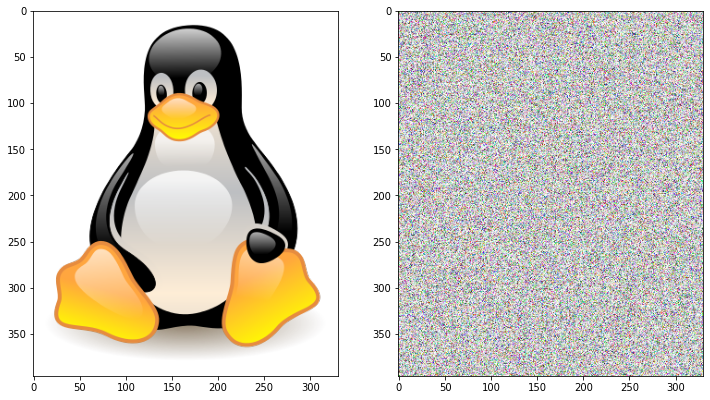

In [15]:
cipher = Cipher(algorithms.AES(key), modes.CBC(iv))
run_aes(cipher)

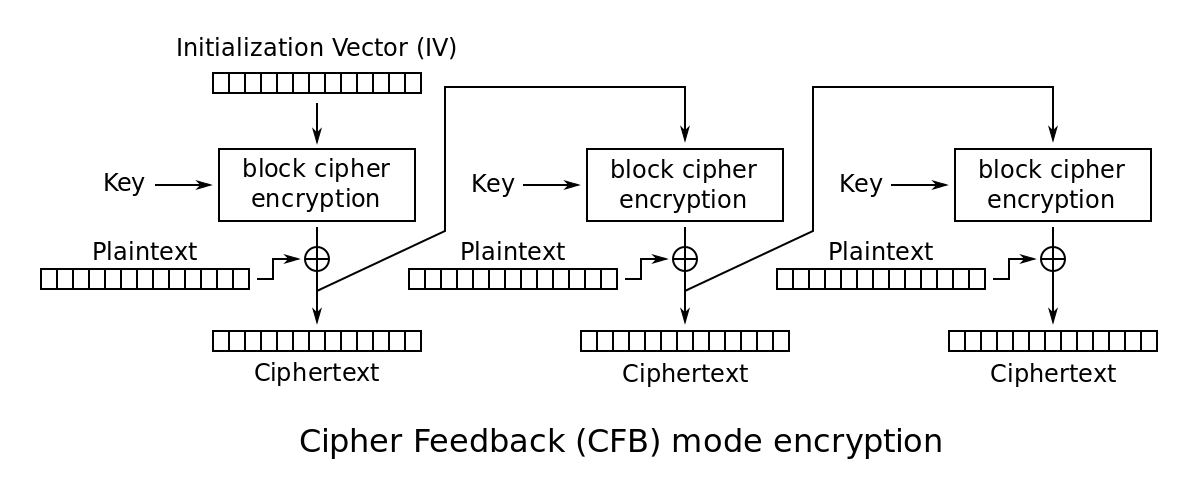

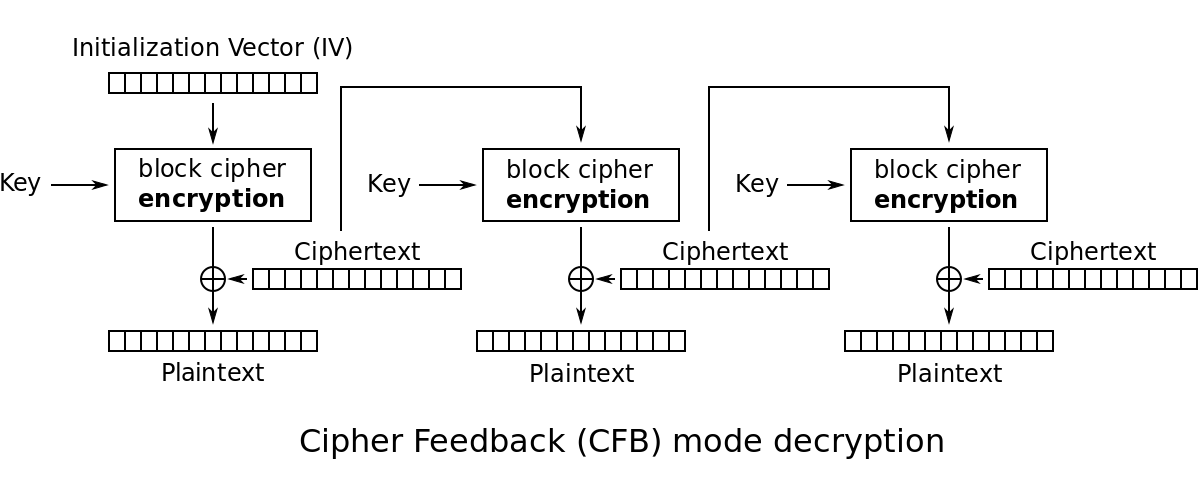

b'Plain Text : None of them noticed a large, tawny owl flutter past the window.'
b'Padded Text : None of them noticed a large, tawny owl flutter past the window.\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10'
b'Padded Cipher : A&\x884\xb3\xb1\x8c\x19\xb1\x11\xfc?y\xacc\xfd]\xd8\x90U>B\xe2\x83\xc6-\x7fA+FX\xb8\xca\xb9\xe4\xc8\x1b~\x1f=\x02\xa1a\xe2Qa\x0be$k;\xf6\x15\xad\x93\xc4+\x8e\x1e9\nn\xe8\x10Yp\x16R-\x86"M\xbf\xd0\x06\xc7\x10\t\x99\x18'
b'Padded Data : None of them noticed a large, tawny owl flutter past the window.\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10'
b'Unpadded Data : None of them noticed a large, tawny owl flutter past the window.'

b"Plain Text : Hermione: Are you sure that's a real spell? Well, it's not very good, is it? Of course I've only tried a few simple spells myself, and they've all worked for me. For example...{Hermione goes over and sits across from Harry. He points her hand at his glasses and Harry tenses} Oculus Reparo.

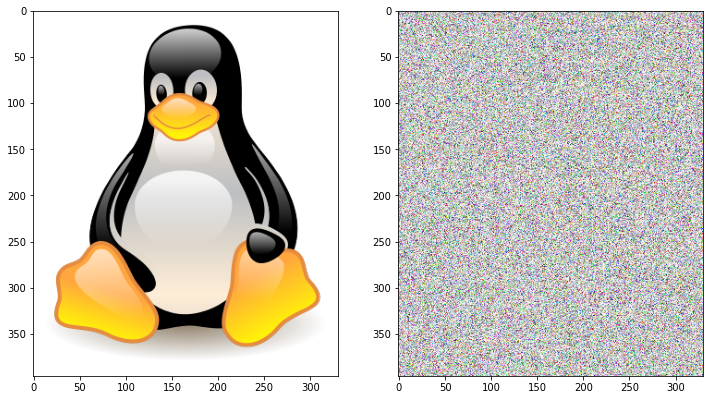

In [16]:
cipher = Cipher(algorithms.AES(key), modes.CFB(iv))
run_aes(cipher)

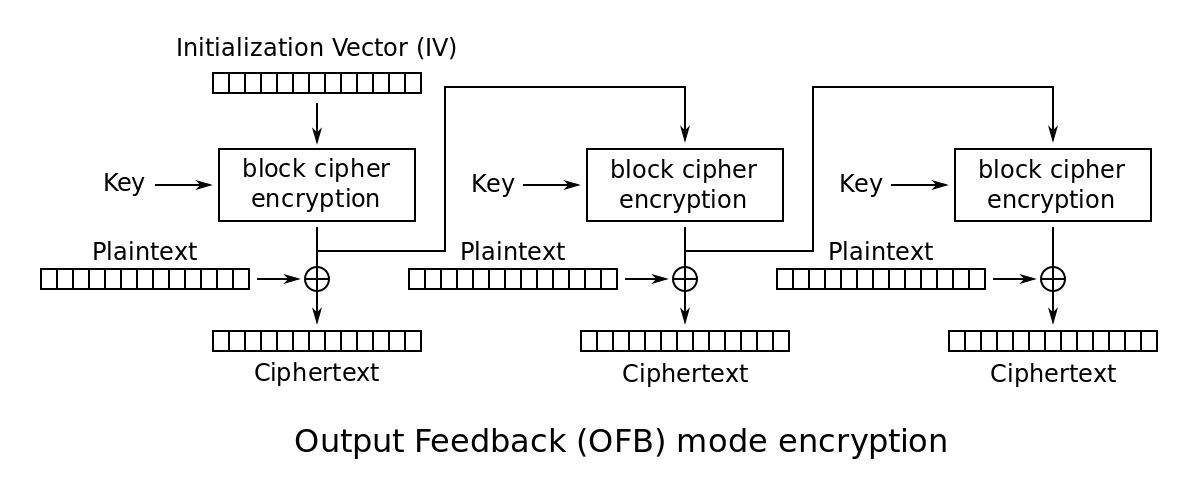

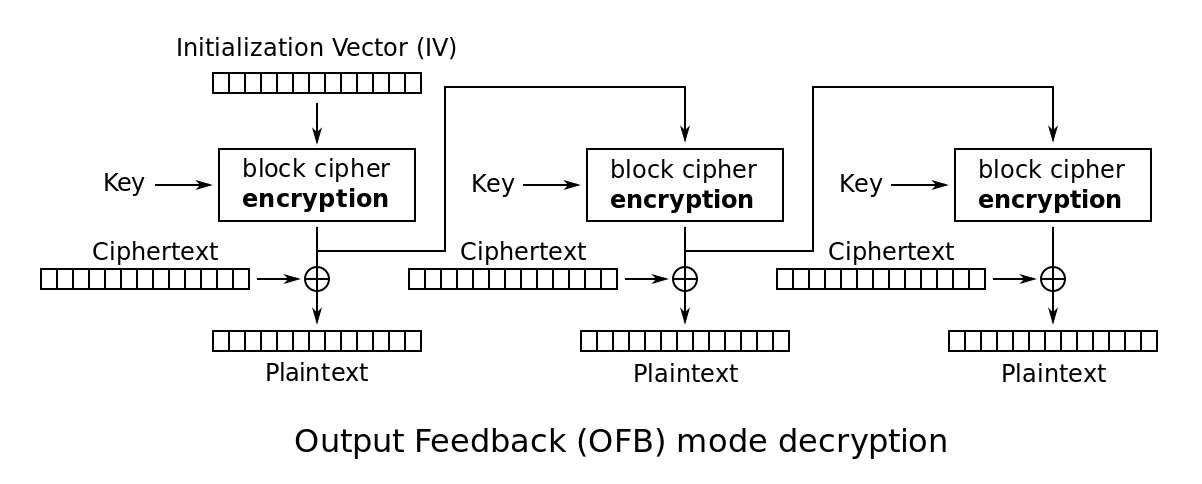

b'Plain Text : None of them noticed a large, tawny owl flutter past the window.'
b'Padded Text : None of them noticed a large, tawny owl flutter past the window.\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10'
b'Padded Cipher : A&\x884\xb3\xb1\x8c\x19\xb1\x11\xfc?y\xacc\xfdVs\x01\xa4\xbb\xa7KD\x87\x7f\x8a\xban\x85\xd3r\x86i\xd1]Z\xd1\xc6\xd7\x9a\x9bH\xd7\x14\xf2\x8b&N\x95\xa5\xa3\xe2\xccT\xcf\x80\xaeE\x98\x17\x924\xeb\x89@\xe4m\xa1\xa3\x80[\xe9S\xeb\x89\xe0\n\xb5('
b'Padded Data : None of them noticed a large, tawny owl flutter past the window.\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10'
b'Unpadded Data : None of them noticed a large, tawny owl flutter past the window.'

b"Plain Text : Hermione: Are you sure that's a real spell? Well, it's not very good, is it? Of course I've only tried a few simple spells myself, and they've all worked for me. For example...{Hermione goes over and sits across from Harry. He points her hand at his glasses and Harry

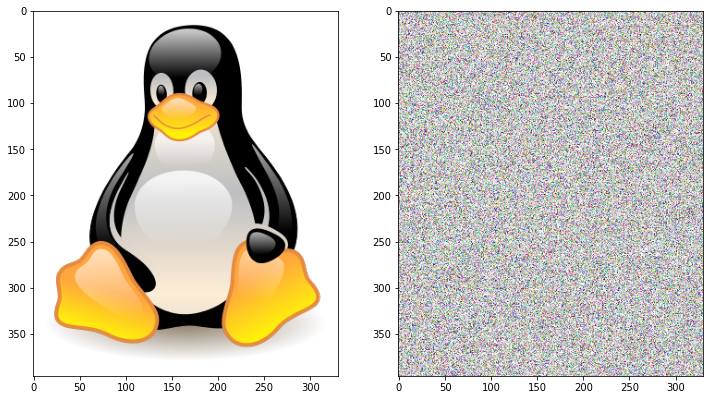

In [17]:
cipher = Cipher(algorithms.AES(key), modes.OFB(iv))
run_aes(cipher)

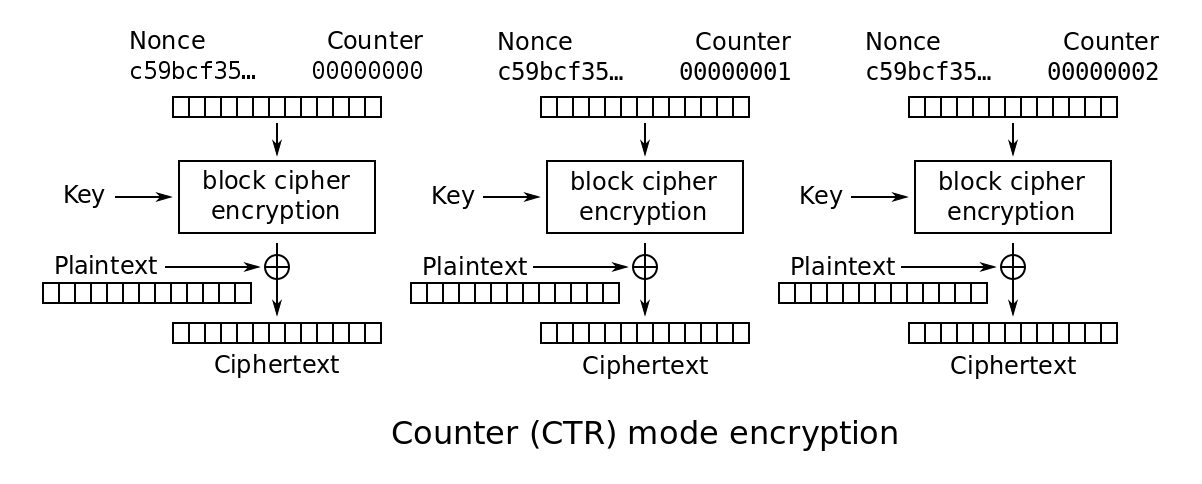

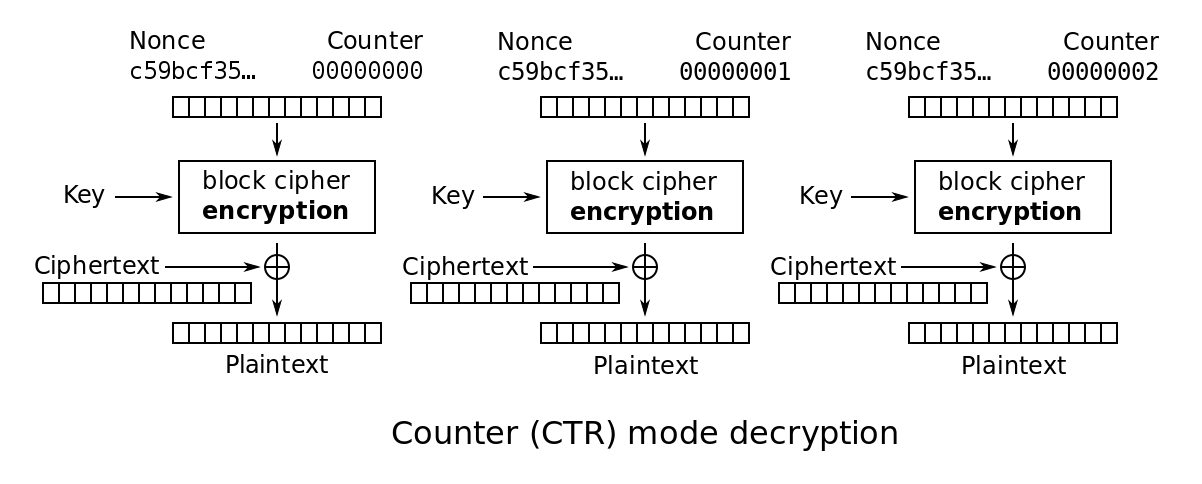

b'Plain Text : None of them noticed a large, tawny owl flutter past the window.'
b'Padded Text : None of them noticed a large, tawny owl flutter past the window.\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10'
b'Padded Cipher : A&\x884\xb3\xb1\x8c\x19\xb1\x11\xfc?y\xacc\xfd\xaf\x17\xe2"[\xcb\xce\x19u\xf2\xaf\xf1@b `\xf6\xb5\x1d\xde\xf6R\xd0\x1f\x1e^Tt\nCI\xdf\xad+\xc2\x11~v\xf8\xcd\xdd\x05+\x99\x9ey]\xb3\x1c\xe2>Z\x02(\x11\xc7\xa2\xe2\xe8\xd4|NaZ'
b'Padded Data : None of them noticed a large, tawny owl flutter past the window.\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10'
b'Unpadded Data : None of them noticed a large, tawny owl flutter past the window.'

b"Plain Text : Hermione: Are you sure that's a real spell? Well, it's not very good, is it? Of course I've only tried a few simple spells myself, and they've all worked for me. For example...{Hermione goes over and sits across from Harry. He points her hand at his glasses and Harry tenses} Oculus Re

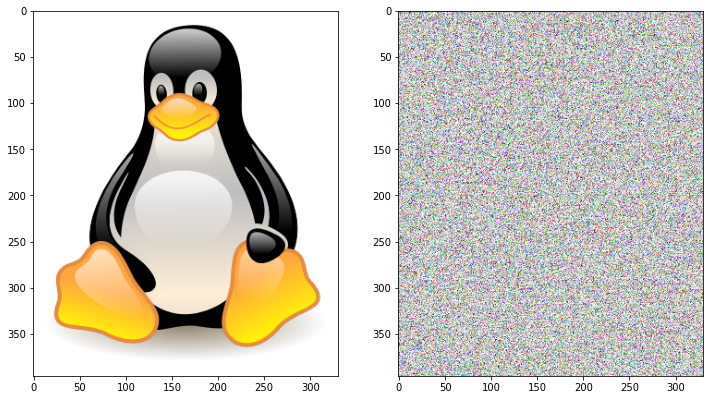

In [18]:
cipher = Cipher(algorithms.AES(key), modes.CTR(iv))
run_aes(cipher)